# Setup 


In [70]:
import tensorflow as tf
import os

In [71]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)


In [72]:
tf.config.list_physical_devices('GPU')

[]

# Removing Corrupted Images

In [73]:
import cv2
import imghdr

In [74]:
data_dir = 'data' 
image_exts = ['jpeg','jpg', 'bmp', 'png']

In [75]:
for image_class in os.listdir(data_dir): 
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try: 
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts: 
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e: 
            print('Issue with image {}'.format(image_path))
            # os.remove(image_path)

# Load Data

In [76]:
import numpy as np
from matplotlib import pyplot as plt

In [77]:
data = tf.keras.utils.image_dataset_from_directory('data',batch_size=16)

Found 190 files belonging to 2 classes.


In [78]:
data_iterator = data.as_numpy_iterator()

In [79]:
batch = data_iterator.next()
_1,_2=batch
print(_1.shape)
print(_2.shape)

(16, 256, 256, 3)
(16,)


We can see in the below image that Jai - Class 1 and Dad - Class 0

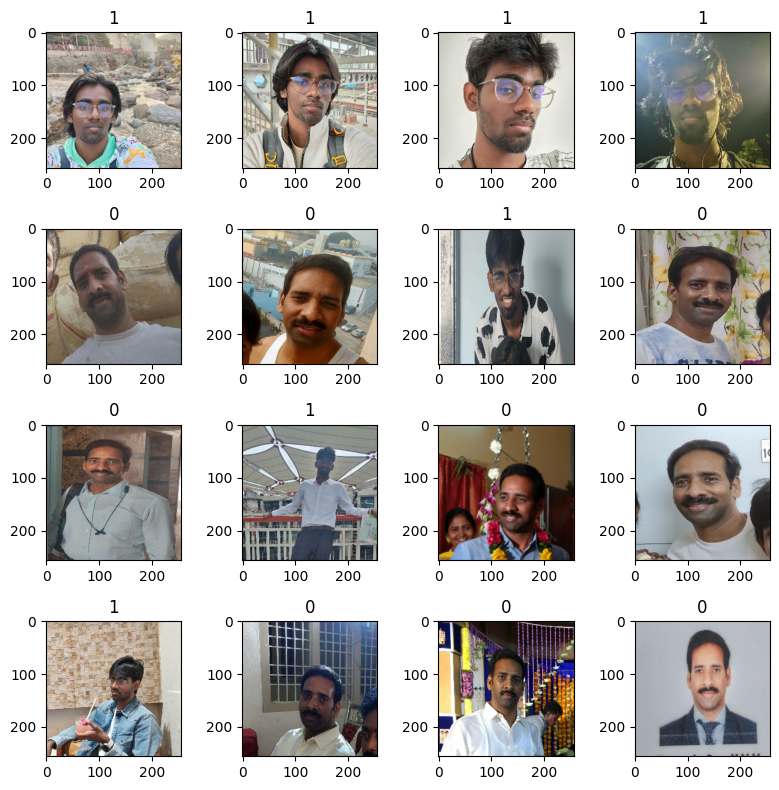

In [80]:
# Assuming `batch` contains the images and labels, and batch[0] has images, batch[1] has labels.
batch_size = 16
fig, ax = plt.subplots(nrows=4, ncols=4, figsize=(8, 8))  # 4x4 grid for 16 images
ax = ax.flatten()  # Flatten the 2D array of axes to easily access them in a loop

for idx, img in enumerate(batch[0][:batch_size]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])  # Assuming labels are in batch[1]

plt.tight_layout()  # Adjust layout to prevent overlapping of titles/labels
plt.show()

# Scale Data

In [81]:
data = data.map(lambda x,y: (x/255, y))

In [82]:
data.as_numpy_iterator().next()

(array([[[[0.4656493 , 0.4538846 , 0.41960335],
          [0.5434649 , 0.5317002 , 0.49774438],
          [0.19165955, 0.17989485, 0.14626457],
          ...,
          [0.700443  , 0.7043646 , 0.71220773],
          [0.67508256, 0.67900413, 0.68684727],
          [0.47970423, 0.4836258 , 0.49146894]],
 
         [[0.32299396, 0.31122926, 0.28570843],
          [0.39825118, 0.38648647, 0.36246684],
          [0.2861508 , 0.2743861 , 0.25186774],
          ...,
          [0.39106345, 0.39498502, 0.40282816],
          [0.36653   , 0.37045157, 0.3782947 ],
          [0.49895313, 0.5028747 , 0.5107178 ]],
 
         [[0.392006  , 0.37777206, 0.3634951 ],
          [0.36678982, 0.3518683 , 0.33909258],
          [0.28656024, 0.27095115, 0.25967664],
          ...,
          [0.4713783 , 0.47497052, 0.48281366],
          [0.68506855, 0.68866074, 0.6965039 ],
          [0.3298329 , 0.33342513, 0.34126827]],
 
         ...,
 
         [[0.65831274, 0.64229715, 0.50603026],
          [0.65624

# Split Data

In [83]:
len(data)

12

In [84]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.3)
test_size = int(len(data)*.1)

In [85]:
print(train_size,val_size,test_size)

8 3 1


In [86]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

# Making the Convolution Neural Network Model

In [87]:
train

<_TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [88]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [89]:
model = Sequential()

In [90]:


model.add(Conv2D(16, (3,3), 1, activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D())
model.add(Dropout(0.25))

model.add(Conv2D(32, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Dropout(0.25))

model.add(Conv2D(16, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))


c:\Users\yjais\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [91]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [92]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

# Training the Model

In [93]:
logdir='logs'

In [94]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [95]:
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step - accuracy: 0.4817 - loss: 1.6989 - val_accuracy: 0.5417 - val_loss: 0.6861
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.5625 - loss: 0.6833 - val_accuracy: 0.5833 - val_loss: 0.6927
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.5929 - loss: 0.6819 - val_accuracy: 0.5417 - val_loss: 0.6929
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 0.4862 - loss: 0.6937 - val_accuracy: 0.5208 - val_loss: 0.6930
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.5614 - loss: 0.6858 - val_accuracy: 0.4792 - val_loss: 0.6931
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.5220 - loss: 0.6918 - val_accuracy: 0.5833 - val_loss: 0.6914
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 0.4972 - loss: 0.6845 - val_accuracy: 0.6250 - val_loss: 0.6752
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.5485 - loss: 0.7007 - val_accuracy: 0.6458 - val_loss: 0.6854
Epo

# Visualization of Performance

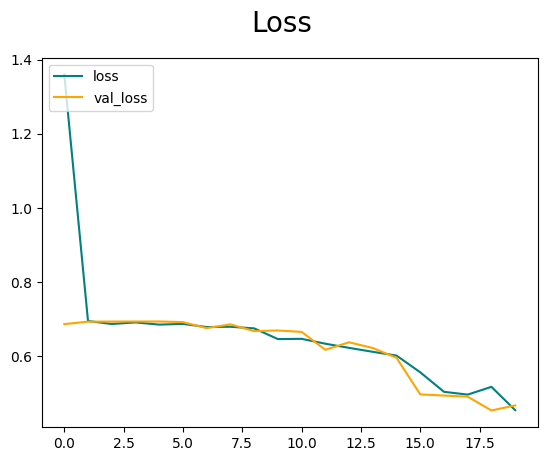

In [96]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

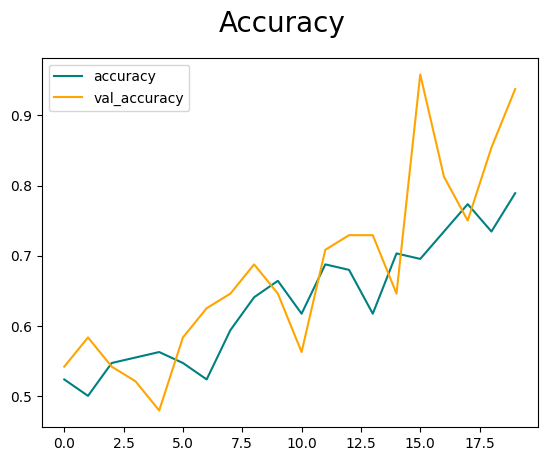

In [97]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

# Performance Metrics with the Test Set

In [98]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [99]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [100]:
for batch in test.as_numpy_iterator(): 
    X, y = batch
    yhat = model.predict(X)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


In [101]:
from sklearn.metrics import classification_report
yhat = (yhat >= 0.5).astype(int)  # Convert probabilities to binary predictions

# Define target names 
target_names = ['Dad Image', 'Jai Image']

# Print classification report
print(classification_report(y, yhat, target_names=target_names))

              precision    recall  f1-score   support

   Dad Image       1.00      0.83      0.91         6
   Jai Image       0.89      1.00      0.94         8

    accuracy                           0.93        14
   macro avg       0.94      0.92      0.93        14
weighted avg       0.94      0.93      0.93        14



In [102]:
# Print the results
print("Precision:", pre.result().numpy())
print("Recall:", re.result().numpy())
print("Accuracy:", acc.result().numpy())

print(y)
print(yhat.flatten())

Precision: 0.8888889
Recall: 1.0
Accuracy: 0.9285714
[0 1 0 1 1 1 1 0 1 0 1 1 0 0]
[0 1 0 1 1 1 1 1 1 0 1 1 0 0]


# Manual Testing

Found 10 files belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


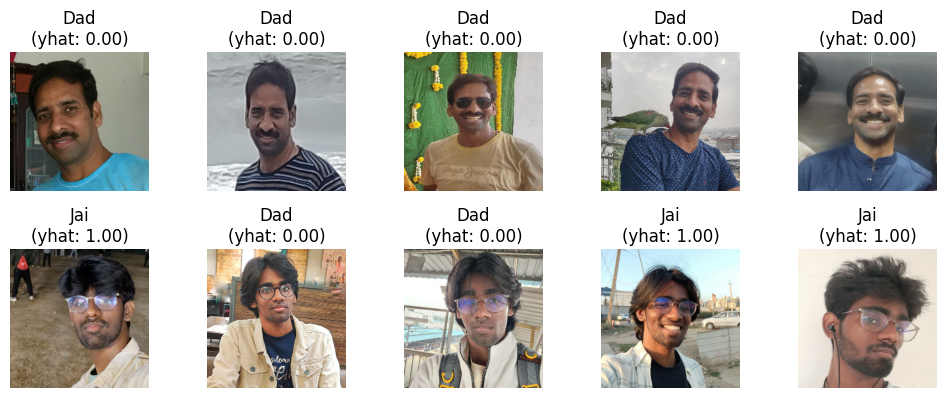

In [103]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt
import numpy as np
import os

# Load images from directory
directory_path = 'manual_testing' 
batch_size = 32
img_size = (256, 256)

# Create dataset
dataset = image_dataset_from_directory(
    directory_path,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

# Predict function
def predict_and_plot(model, dataset, n=25):
    plt.figure(figsize=(10, 10))
    images_shown = 0
    
    for images, _ in dataset:
        # Predict on batch
        yhat = model.predict(images)
        
        # Loop through each image and plot
        for i in range(images.shape[0]):
            if images_shown >= n:
                break
            
            # Get the prediction and label
            prediction = "Jai" if yhat[i] > 0.5 else "Dad"
            confidence = yhat[i][0]
            
            # Plot the image
            ax = plt.subplot(5, 5, images_shown + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(f"{prediction}\n(yhat: {confidence:.2f})")
            plt.axis("off")
            
            images_shown += 1
        
        if images_shown >= n:
            break
    
    plt.tight_layout()
    plt.show()

# Use the function with your model
predict_and_plot(model, dataset)
